In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('california_housing_train.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [3]:
df.shape

(17000, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [5]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64

In [6]:
df.corr()['population']

longitude             0.101674
latitude             -0.111261
housing_median_age   -0.295890
total_rooms           0.860170
total_bedrooms        0.881169
population            1.000000
households            0.909247
median_income        -0.000638
median_house_value   -0.027850
Name: population, dtype: float64

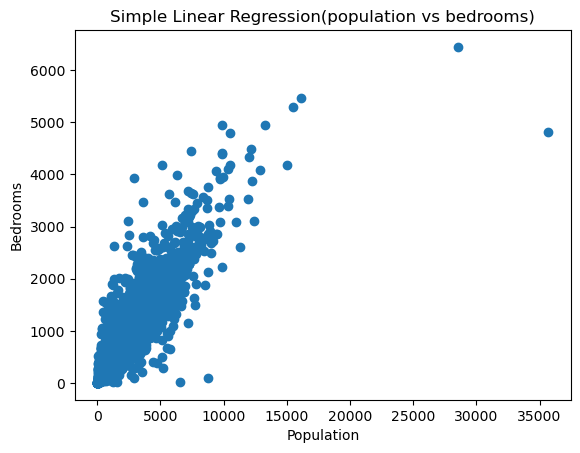

In [7]:
df['population']
df['total_bedrooms']
import matplotlib.pyplot as plt
plt.scatter(df['population'],df['total_bedrooms'])
plt.xlabel("Population")
plt.ylabel("Bedrooms")
plt.title("Simple Linear Regression(population vs bedrooms)")
plt.show()

In [8]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(df[['population']],df['total_bedrooms'])

LinearRegression()

In [9]:
model_pred = model.predict(df[['population']])
model_pred = model_pred.astype(int)
model_pred

array([405, 442, 184, ..., 479, 496, 337])

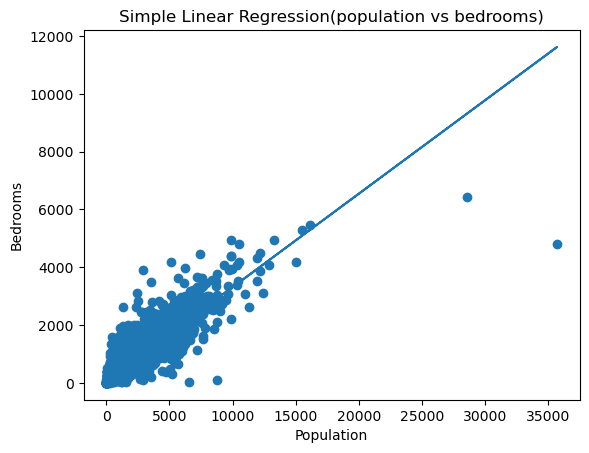

In [10]:
plt.scatter(df['population'],df['total_bedrooms'])           #after predictions ##... line represents the best fit line
plt.plot(df[['population']],model_pred)
plt.xlabel("Population")
plt.ylabel("Bedrooms")
plt.title("Simple Linear Regression(population vs bedrooms)")
plt.show()

In [11]:
dframe = pd.DataFrame({'Population':df['population'].astype(int),
                       'Actual_Bedrooms':df['total_bedrooms'].astype(int),
                       'Model_Bedrooms(Predicted)':model_pred
                      })
dframe.head()

,Population,Actual_Bedrooms,Model_Bedrooms(Predicted)
0,1015,1283,405
1,1129,1901,442
2,333,174,184
3,515,337,243
4,624,326,278


In [12]:
from sklearn.metrics import r2_score,mean_absolute_error
from sklearn.metrics import mean_squared_error
reg_acc = r2_score(df['total_bedrooms'],model_pred)
print(f"r2 score(model):{reg_acc:.2f}")

r2 score(model):0.78


In [13]:
mse = mean_squared_error(df['total_bedrooms'],model_pred)
mae = mean_absolute_error(df['total_bedrooms'],model_pred)
print(f"mean squared error:{mse:.2f}")
print("mean absolute error:",mae.round(2))

mean squared error:39712.94
mean absolute error: 118.36


In [14]:
import math
rmse = math.sqrt(mse)
print(f"Root mean square error:{rmse:.2f}")

Root mean square error:199.28


In [15]:
# slope and intercept
print("Intercept for my model:(c):",model.intercept_)
print("Slope(coefficient):",model.coef_[0])


Intercept for my model:(c): 76.84197820308816
Slope(coefficient): 0.3235711228379357


In [16]:
import warnings
warnings.filterwarnings('ignore')

In [17]:
import numpy as np
population = np.array([450]).reshape(1,-1)
new_bedrooms = model.predict(population)
print(f"No of bedrooms needed for {population}:{new_bedrooms.astype(int)}")

No of bedrooms needed for [[450]]:[222]


In [18]:
arr = np.array([1,2,3])
print(arr.ndim)
print(arr.shape)

1
(3,)


In [19]:
arr = arr.reshape(1,-1)
print(arr.ndim)
print(arr.shape)

2
(1, 3)


MULTIPLE LINEAR REGression

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [22]:
home = pd.read_csv('california_housing_train.csv')
home.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [23]:
home.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64

In [24]:
X = home.drop('median_house_value',axis =1)
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250


In [25]:
Y = home['median_house_value']
Y.head()

0    66900.0
1    80100.0
2    85700.0
3    73400.0
4    65500.0
Name: median_house_value, dtype: float64

In [26]:
Y.shape

(17000,)

In [27]:
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [28]:
x_train.shape,x_test.shape

((13600, 8), (3400, 8))

In [29]:
X.shape

(17000, 8)

In [30]:
#Feature scaling
from sklearn.preprocessing import StandardScaler

scale = StandardScaler()

X_train_scaled = scale.fit_transform(x_train)
#X_test_scaled = scale.transform(x_test)
X_train_scaled

array([[ 0.74182975, -0.84715727, -0.52839839, ..., -0.1093373 ,
        -0.34660377,  2.44336202],
       [ 0.96140556, -0.99243346, -1.32221004, ...,  0.06388797,
        -0.02353959,  1.74194208],
       [ 1.23088496, -1.42826202, -0.92530422, ..., -0.92634004,
        -1.07870889,  0.66656067],
       ...,
       [ 0.70190687, -0.80029399,  0.74170025, ..., -0.57902769,
        -0.76346077, -0.47689942],
       [ 1.24086568, -1.43294835, -1.56035354, ...,  1.60395538,
         0.88312441, -0.40625469],
       [-1.42398618,  0.99925621,  1.85303657, ...,  0.43102211,
         0.12496572, -0.777493  ]])

In [31]:
from sklearn.preprocessing import StandardScaler

scale = StandardScaler()

X_train_scaled = scale.fit_transform(x_train)
X_train_scaled = pd.DataFrame(X_train_scaled,columns=X.columns)
X_train_scaled.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,0.741830,-0.847157,-0.528398,0.033111,-0.445165,-0.109337,-0.346604,2.443362
1,0.961406,-0.992433,-1.322210,0.451867,-0.008317,0.063888,-0.023540,1.741942
2,1.230885,-1.428262,-0.925304,-1.012397,-1.083819,-0.926340,-1.078709,0.666561
3,1.195952,-1.315790,0.424176,-0.167966,-0.390559,-0.354093,-0.317945,-0.124566
4,0.741830,-0.678449,0.582938,-0.103400,-0.345450,-0.186901,-0.229363,0.872891


In [32]:
X_test_scaled = scale.fit_transform(x_test)
X_test_scaled = pd.DataFrame(X_test_scaled,columns=X.columns)
X_test_scaled.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-0.639609,0.983333,-1.540819,0.978016,0.901381,0.948315,1.087271,-0.169373
1,0.718655,-0.718515,1.888383,0.036173,-0.276932,-0.243916,-0.227173,2.205381
2,-0.231632,0.615994,-0.982577,0.468899,0.473119,0.951052,0.503648,-0.730449
3,1.076878,-0.760364,-1.540819,1.255266,0.811470,1.454580,0.919415,0.165138
4,0.658951,-0.783614,1.888383,-0.597863,-0.456755,-0.252126,-0.361458,-1.254247


In [33]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [34]:
y_pred = lr.predict(x_test)
y_pred = y_pred.astype(int)
y_pred

array([143770, 398615,  86341, ...,  26482, 283556, 115808])

In [35]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_pred)
r2

0.6636395645305773

In [36]:
print(f"Accuracy of our model(lr):{r2:.2f}")

Accuracy of our model(lr):0.66


In [37]:
print(f"Accuracy of our model(lr):{r2*100:.2f}")

Accuracy of our model(lr):66.36


In [38]:
# comparing acc with another alg.

import xgboost                                               #xgboost will give more accuracy by decision trees
from xgboost import XGBRegressor
xb = XGBRegressor()

In [39]:
xb.fit(X_train_scaled,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [40]:
modelpreds = xb.predict(X_test_scaled)
modelpreds = modelpreds.astype(int)
modelpreds

array([152202, 472606,  67325, ...,  96099, 474330, 159387])

In [41]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test,modelpreds)
print(f"Accuracy of our model(xb):{r2:.2f}")

Accuracy of our model(xb):0.79


In [42]:
#implementing same xgboost with hyperparameters
import xgboost                                               #xgboost will give more accuracy by decision trees
from xgboost import XGBRegressor
xb_para = XGBRegressor(n_estimators=500,
                    learning_rate=0.05,
                    max_depth = 4,
                    random_state=42
                    )
xb_para.fit(X_train_scaled,y_train)
modelpreds_para = xb_para.predict(X_test_scaled)
modelpreds_para = modelpreds_para.astype(int)
modelpreds_para

from sklearn.metrics import r2_score
r2 = r2_score(y_test,modelpreds_para)
print(f"Accuracy of our model(xb):{r2:.2f}")

Accuracy of our model(xb):0.80
